# 📊 EDA01 - App Insights Analysis

## Project Overview

The mobile application industry has experienced rapid growth, with millions of applications available on the Google Play Store. Understanding what makes an application successful is essential for developers, product managers, and business stakeholders. This project performs an Exploratory Data Analysis (EDA) on the Google Play Store dataset to identify the factors influencing app ratings, installs, reviews, pricing, and overall success.

The analysis focuses on discovering trends, relationships, and user behavior that can help organizations make data-driven decisions for future app development and marketing strategies.

---

## Problem Statement

A technology company has acquired a dataset containing information about applications available on the Google Play Store. The objective is to analyze the dataset and uncover insights regarding app performance, user preferences, pricing strategies, and category trends.

The findings will help stakeholders understand the characteristics of successful applications and support better business decisions.

---

## Objectives

- Perform data cleaning and preprocessing.
- Understand the overall structure of the dataset.
- Analyze app ratings, installs, reviews, and pricing.
- Identify the most popular app categories.
- Study the relationship between app size, ratings, and installs.
- Discover factors contributing to successful applications.
- Generate actionable business insights and recommendations.

---

## Stakeholders

### Internal Stakeholders
- App Developers
- Product Managers
- Marketing Team
- Senior Management

### External Stakeholders
- App Users
- Advertisers
- Business Partners

---

## Dataset Information

**Dataset Name:** Google Play Store Apps Dataset

**Source:** Kaggle

The dataset contains information about Google Play Store applications including:

- App Name
- Category
- Rating
- Reviews
- Size
- Installs
- Type
- Price
- Content Rating
- Genres
- Last Updated
- Current Version
- Android Version

In [93]:
import os

os.makedirs("Images", exist_ok=True)

def save_plot(filename):
    plt.savefig(
        f"Images/{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

In [1]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Set visualization style
plt.style.use("ggplot")
sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load dataset

df = pd.read_csv("googleplaystore.csv")

In [3]:
# Display first five rows

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 10841
Number of Columns : 13


In [5]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

# Data Understanding

Before performing any analysis, it is important to understand the structure and quality of the dataset. This section examines the dataset's dimensions, data types, missing values, duplicate records, statistical summaries, and unique values. These observations will help identify the preprocessing steps required before exploratory data analysis.

In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
# Statistical summary of numerical columns

df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [8]:
# Summary of all columns

df.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Missing values in each column

df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [10]:
# Total duplicate rows

df.duplicated().sum()

np.int64(483)

In [11]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [12]:
df.nunique()

App               9660
Category            34
Rating              40
Reviews           6002
Size               462
Installs            22
Type                 3
Price               93
Content Rating       6
Genres             120
Last Updated      1378
Current Ver       2832
Android Ver         33
dtype: int64

In [13]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 10841
Columns : 13


In [14]:
df.sample(5, random_state=42)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3457,Microsoft Outlook,PRODUCTIVITY,4.3,3252896,50M,"100,000,000+",Free,0,Everyone,Productivity,"August 2, 2018",2.2.194,4.4 and up
3069,FotMob - Live Soccer Scores,SPORTS,4.7,410395,Varies with device,"10,000,000+",Free,0,Everyone,Sports,"July 31, 2018",Varies with device,Varies with device
9657,EO Guide,HEALTH_AND_FITNESS,NaN,15,24M,"1,000+",Paid,$4.99,Everyone,Health & Fitness,"July 23, 2018",1.0.4,4.1 and up
10714,FunForMobile Ringtones & Chat,SOCIAL,4.4,68358,7.2M,"5,000,000+",Free,0,Mature 17+,Social,"May 7, 2016",3.22,4.1 and up
3963,Oral-B App,HEALTH_AND_FITNESS,3.3,14210,96M,"1,000,000+",Free,0,Everyone,Health & Fitness,"July 19, 2018",6.0.1,5.0 and up


# Data Cleaning and Preprocessing

Data cleaning is an essential step in the data analysis process to ensure accurate and reliable results. Real-world datasets often contain missing values, duplicate records, inconsistent formatting, and incorrect data types that can affect the quality of analysis. In this section, the dataset is cleaned by handling missing values, removing duplicate records, converting columns to appropriate data types, standardizing text fields, and formatting date columns. These preprocessing steps prepare the dataset for effective exploratory data analysis and help generate meaningful business insights.

In [15]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [16]:
# Remove rows with missing values in selected columns

df.dropna(subset=['Type', 'Content Rating', 'Current Ver', 'Android Ver'], inplace=True)

In [17]:
# Fill missing values in Rating with median

df['Rating'].fillna(df['Rating'].median(), inplace=True)

In [18]:
# Verify missing values after cleaning

df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(483)

In [20]:
# Remove duplicate records

df.drop_duplicates(inplace=True)

In [21]:
# Verify duplicate records

df.duplicated().sum()

np.int64(0)

In [22]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 10346
Number of Columns : 13


# Data Type Conversion and Feature Cleaning

Several columns in the dataset are stored as text even though they represent numerical or date values. To perform accurate analysis and visualizations, these columns need to be converted into appropriate data types. In this section, the `Reviews`, `Size`, `Installs`, `Price`, and `Last Updated` columns are cleaned and transformed into a format suitable for analysis.

In [23]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [24]:
df['Reviews'] = pd.to_numeric(df['Reviews'])

In [25]:
df['Reviews'].dtype

dtype('int64')

In [26]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '5.5M', '17M', '39M', '31M',
       '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M', '5.2M',
       '11M', '24M', 'Varies with device', '9.4M', '15M', '10M', '1.2M',
       '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k', '3.6M',
       '5.7M', '8.6M', '2.4M', '27M', '2.7M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [27]:
# Convert KB to MB

df['Size'] = df['Size'].str.replace('M','')

df['Size'] = df['Size'].str.replace('k','')

df['Size'] = df['Size'].replace('Varies with device', np.nan)

df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

In [28]:
df['Size'].head()

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

In [29]:
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+'], dtype=object)

In [30]:
df['Installs'] = df['Installs'].str.replace(',','')

df['Installs'] = df['Installs'].str.replace('+','')

df['Installs'] = pd.to_numeric(df['Installs'])

In [31]:
df['Installs'].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [32]:
df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [33]:
df['Price'] = df['Price'].str.replace('$','')

df['Price'] = pd.to_numeric(df['Price'])

In [34]:
df['Price'].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

In [35]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [36]:
df['Last Updated'].head()

0   2018-01-07
1   2018-01-15
2   2018-08-01
3   2018-06-08
4   2018-06-20
Name: Last Updated, dtype: datetime64[ns]

In [37]:
df.dtypes

App                       object
Category                  object
Rating                   float64
Reviews                    int64
Size                     float64
Installs                   int64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics, patterns, and relationships within the Google Play Store dataset. This section answers the business questions provided in the case study using statistical analysis and visualizations. The insights generated from this analysis will help identify factors contributing to app success, user engagement, and overall market trends.

In [39]:
# Question 1: Average Rating of Apps


average_rating = df['Rating'].mean()

print(f"Average App Rating : {average_rating:.2f}")

Average App Rating : 4.20


In [57]:
# Question 2: Number of Unique Categories


unique_categories = df['Category'].nunique()

print(f"Unique Categories : {unique_categories}")

Unique Categories : 33


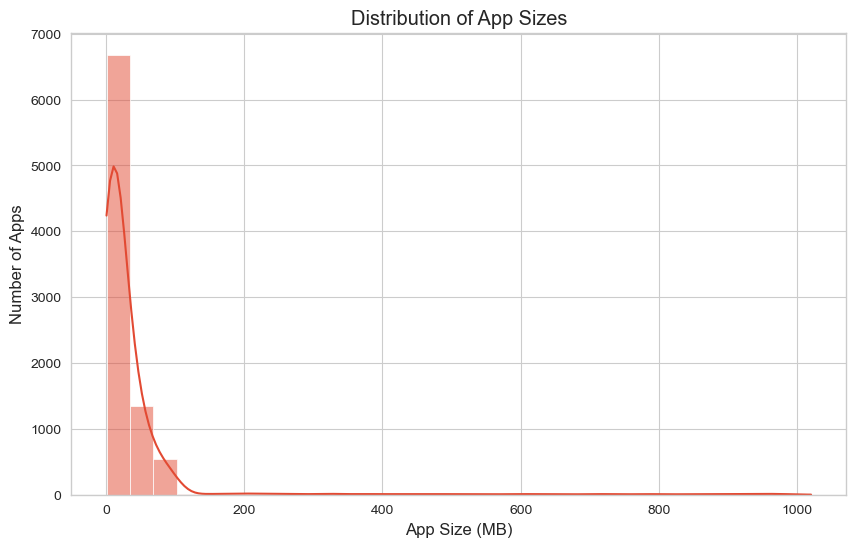

In [94]:
# Question 3: Distribution of App Sizes


plt.figure(figsize=(10,6))

sns.histplot(df['Size'], bins=30, kde=True)

plt.title("Distribution of App Sizes")

plt.xlabel("App Size (MB)")

plt.ylabel("Number of Apps")
save_plot("distribution_of_app_sizes")
plt.show()

In [59]:
# Question 4: Free vs Paid Apps


type_count = df['Type'].value_counts()

print(type_count)

Type
Free    9584
Paid     762
Name: count, dtype: int64


Most Common Content Rating : Everyone


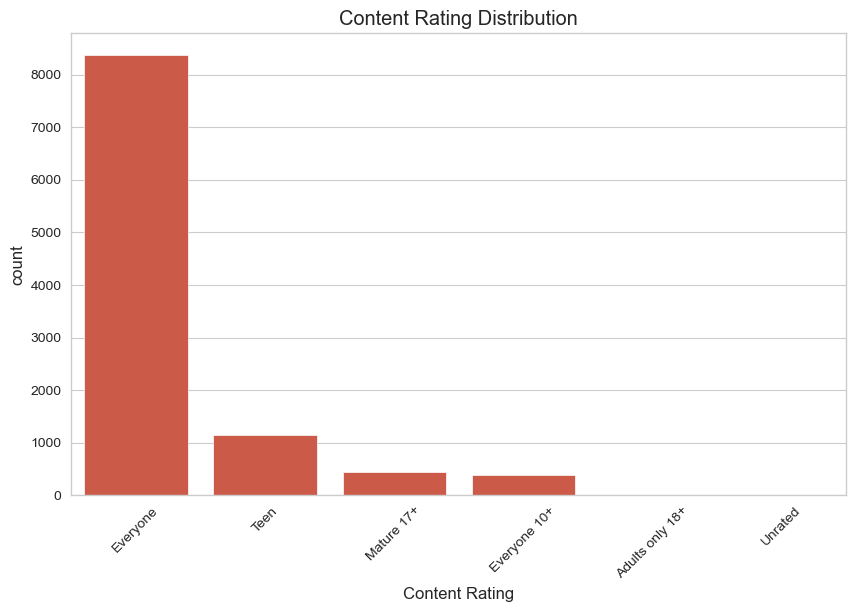

In [96]:
# Question 5: Most Common Content Rating


content_rating = df['Content Rating'].mode()[0]

print("Most Common Content Rating :", content_rating)

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Content Rating',
    order=df['Content Rating'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Content Rating Distribution")
save_plot("Most Common Content Rating")
plt.show()

In [61]:
# Question 6: Top 5 Most Installed Apps


top_apps = df.sort_values(
    by='Installs',
    ascending=False
)[['App','Installs']].head(5)

top_apps



,App,Installs
336,WhatsApp Messenger,1000000000
2554,Google+,1000000000
3127,Google Street View,1000000000
3816,Google News,1000000000
3223,Maps - Navigate & Explore,1000000000


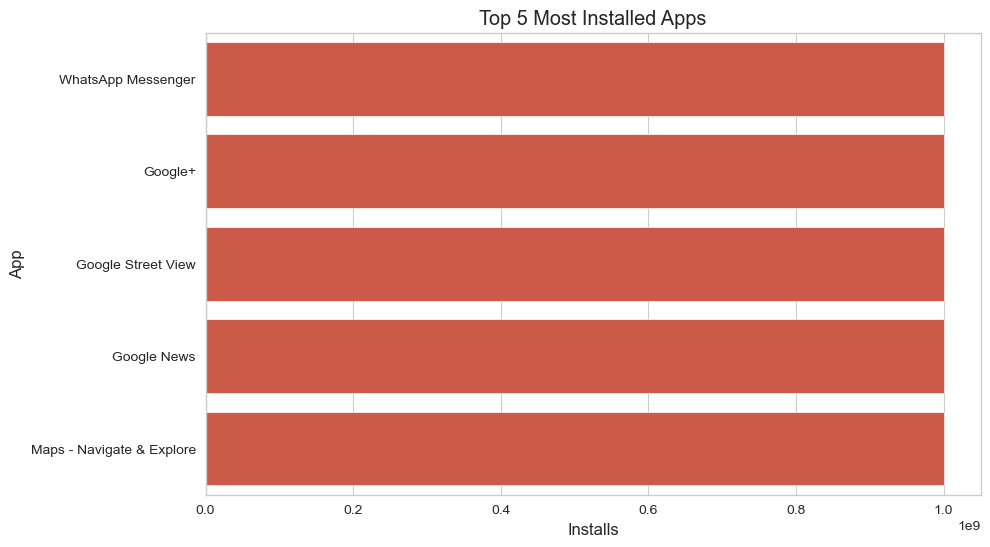

In [97]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_apps,
    x='Installs',
    y='App'
)

plt.title("Top 5 Most Installed Apps")
save_plot("Top 5 Most Installed Apps")
plt.show()

In [62]:
# Question 7: Apps with Rating >= 4


high_rating = df[df['Rating'] >= 4.0]

print("Number of Apps :", high_rating.shape[0])

Number of Apps : 8402


In [63]:
# Question 8: Average Reviews of Free vs Paid Apps


df.groupby('Type')['Reviews'].mean()

Type
Free    437690.492487
Paid     11946.864829
Name: Reviews, dtype: float64

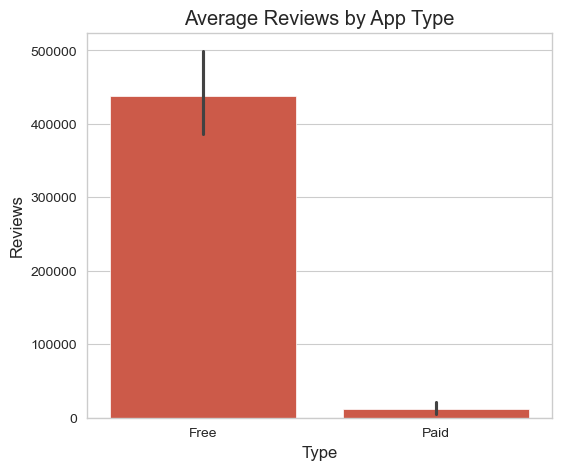

In [98]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x='Type',
    y='Reviews',
    estimator='mean'
)

plt.title("Average Reviews by App Type")
save_plot("Average Reviews by App Type")
plt.show()

In [56]:
# Question 9: Average App Size by Category


average_size = df.groupby('Category')['Size'].mean().sort_values()

average_size

Category
ART_AND_DESIGN          12.529508
BEAUTY                  13.795745
NEWS_AND_MAGAZINES      14.118660
DATING                  15.926966
EVENTS                  19.817544
PHOTOGRAPHY             20.889712
VIDEO_PLAYERS           22.032824
FOOD_AND_DRINK          22.056122
PARENTING               22.512963
ENTERTAINMENT           22.638806
WEATHER                 23.324561
SOCIAL                  25.699507
TRAVEL_AND_LOCAL        25.983799
HOUSE_AND_HOME          26.540323
BUSINESS                26.736412
FINANCE                 29.012171
MAPS_AND_NAVIGATION     31.312963
EDUCATION               31.336458
LIFESTYLE               31.709763
SPORTS                  32.730068
SHOPPING                33.344751
COMICS                  34.111765
AUTO_AND_VEHICLES       34.502667
PRODUCTIVITY            35.822408
BOOKS_AND_REFERENCE     37.199487
FAMILY                  37.686301
HEALTH_AND_FITNESS      38.592917
PERSONALIZATION         42.942045
GAME                    45.575400
MEDIC

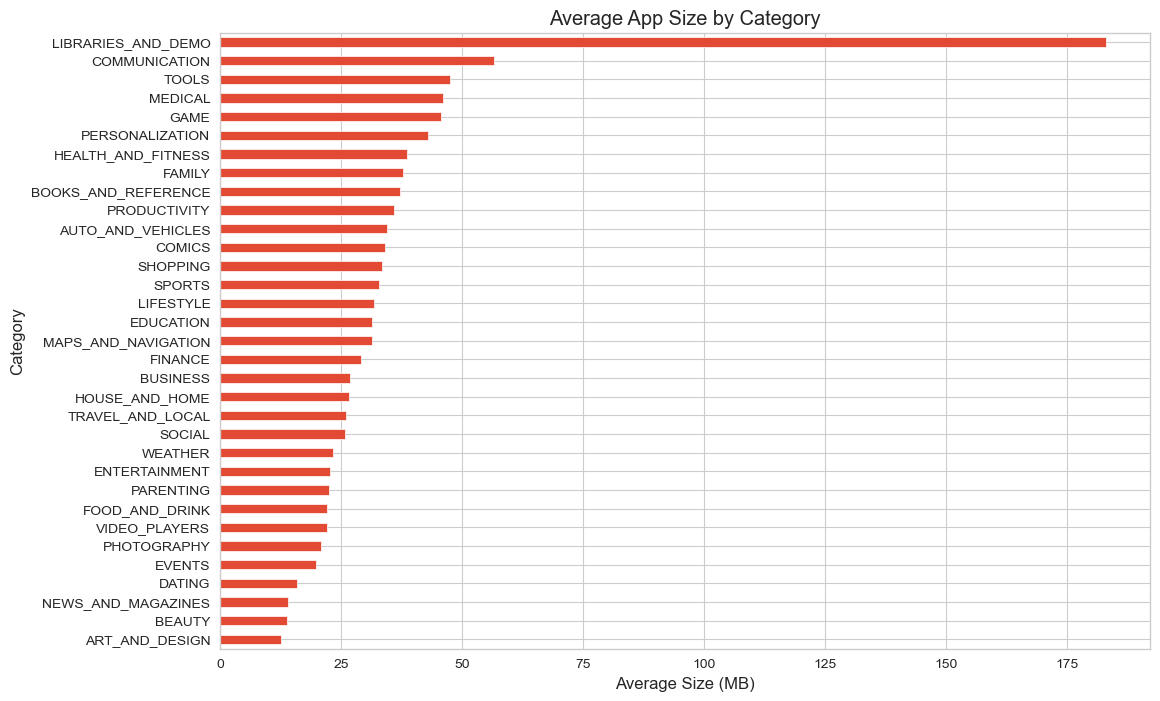

In [99]:
plt.figure(figsize=(12,8))

average_size.plot(kind='barh')

plt.title("Average App Size by Category")

plt.xlabel("Average Size (MB)")
save_plot("Average App Size by Category")
plt.show()

In [55]:
# Question 10: Apps Updated in 2018


apps_2018 = df[df['Last Updated'].dt.year == 2018]

print("Apps Updated in 2018 :", apps_2018.shape[0])

Apps Updated in 2018 : 6929


In [65]:
# Question 11: Correlation Between Installs and Rating

correlation = df['Installs'].corr(df['Rating'])

print(f"Correlation between Installs and Rating: {correlation:.2f}")

Correlation between Installs and Rating: 0.04


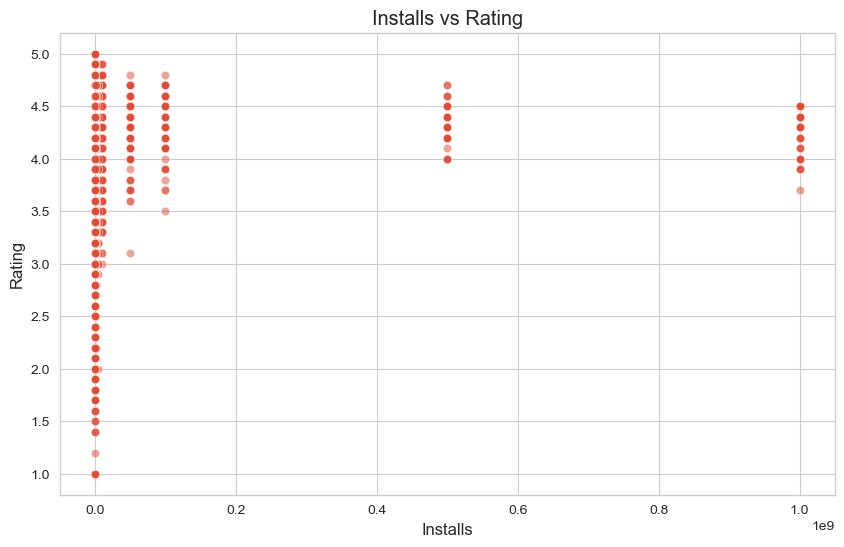

In [100]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='Installs', y='Rating', alpha=0.5)

plt.title("Installs vs Rating")

plt.xlabel("Installs")

plt.ylabel("Rating")
save_plot("Installs vs Rating")
plt.show()

In [67]:
# Question 12: Categories with Highest Average Rating

category_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

category_rating.head(10)

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.373437
BOOKS_AND_REFERENCE    4.336681
PERSONALIZATION        4.326425
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
Name: Rating, dtype: float64

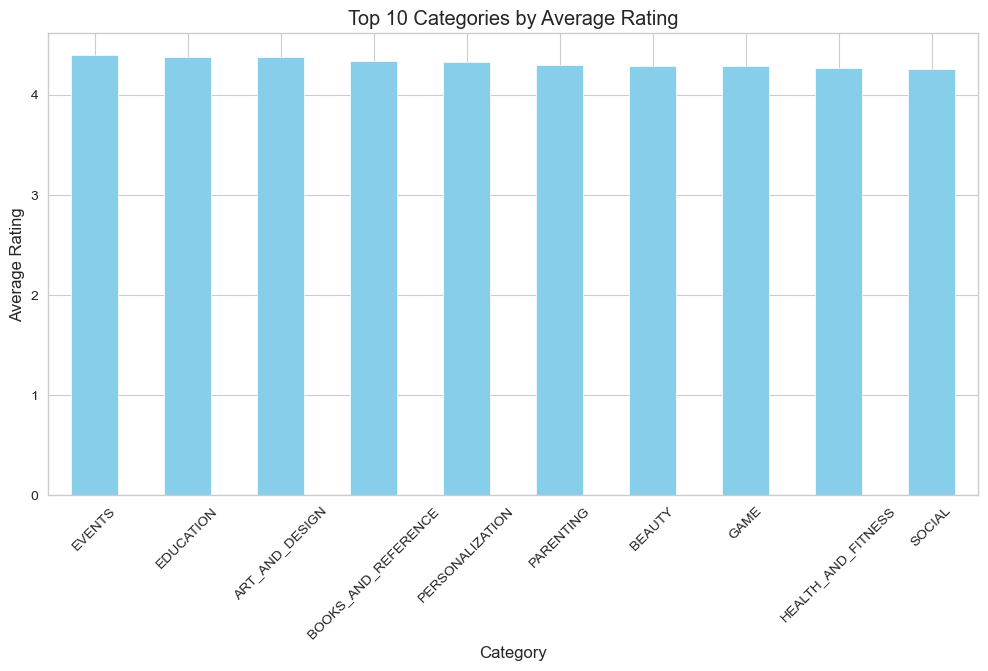

In [101]:
plt.figure(figsize=(12,6))

category_rating.head(10).plot(kind='bar', color='skyblue')

plt.title("Top 10 Categories by Average Rating")

plt.xlabel("Category")

plt.ylabel("Average Rating")

plt.xticks(rotation=45)
save_plot("Top 10 Categories by Average Rating")
plt.show()

In [69]:
# Question 13: Price vs Average Rating

price_rating = df[df['Type'] == 'Paid'].groupby('Price')['Rating'].mean()

price_rating.head(10)

Price
0.99    4.300694
1.00    4.400000
1.04    4.300000
1.20    4.200000
1.26    4.300000
1.29    4.100000
1.49    4.226667
1.50    4.200000
1.59    4.500000
1.61    4.200000
Name: Rating, dtype: float64

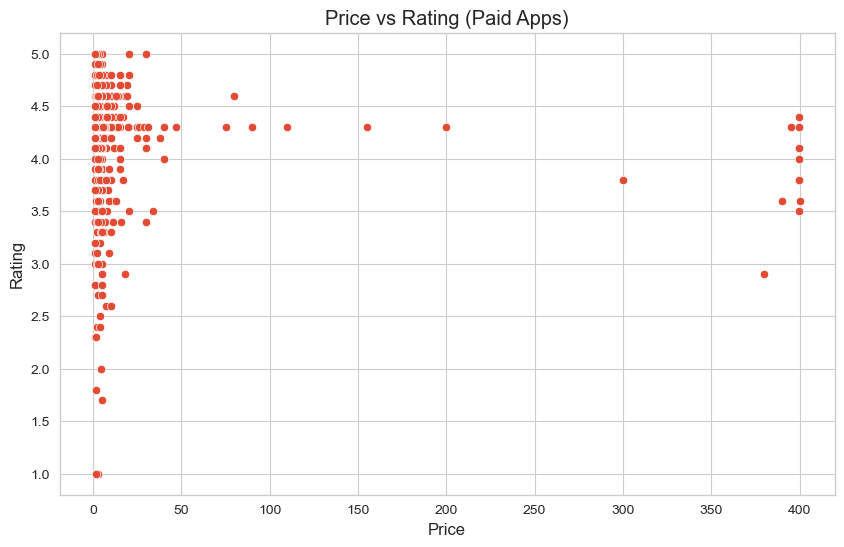

In [103]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df[df['Type']=='Paid'], x='Price', y='Rating')

plt.title("Price vs Rating (Paid Apps)")

plt.xlabel("Price")

plt.ylabel("Rating")
save_plot("Price vs Rating(Paid Apps)")
plt.show()

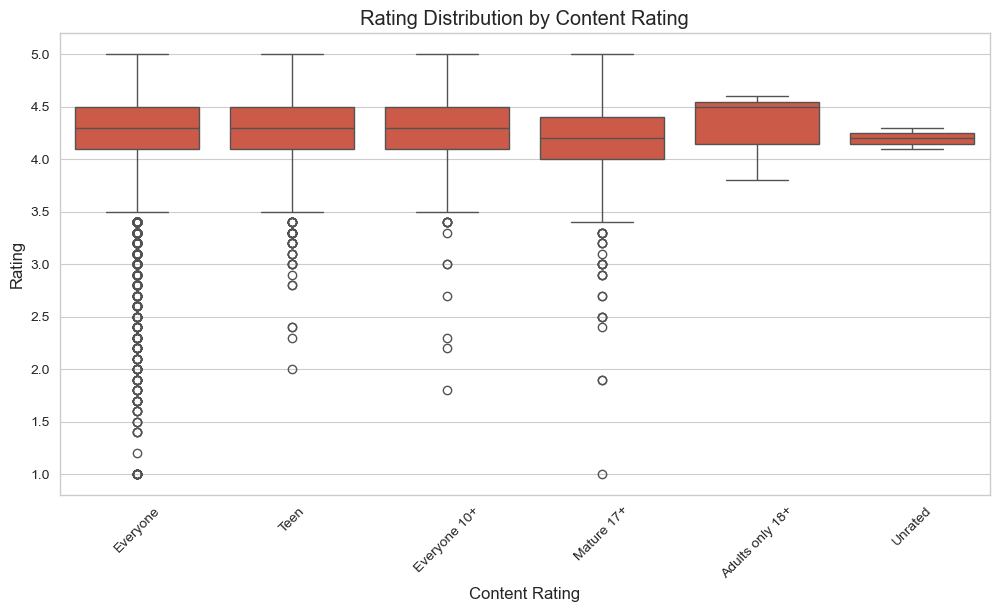

In [104]:
# Question 14: Rating Distribution by Content Rating

plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='Content Rating', y='Rating')

plt.xticks(rotation=45)

plt.title("Rating Distribution by Content Rating")
save_plot("Rating Distribution by Content Rating")
plt.show()

In [72]:
# Question 15: Genres with More Than 1 Million Installs

million_installs = df[df['Installs'] >= 1000000]

genre_installs = million_installs['Genres'].value_counts().head(10)

genre_installs

Genres
Tools               288
Action              237
Photography         213
Communication       191
Productivity        180
Entertainment       179
Sports              156
Arcade              143
Social              141
Health & Fitness    130
Name: count, dtype: int64

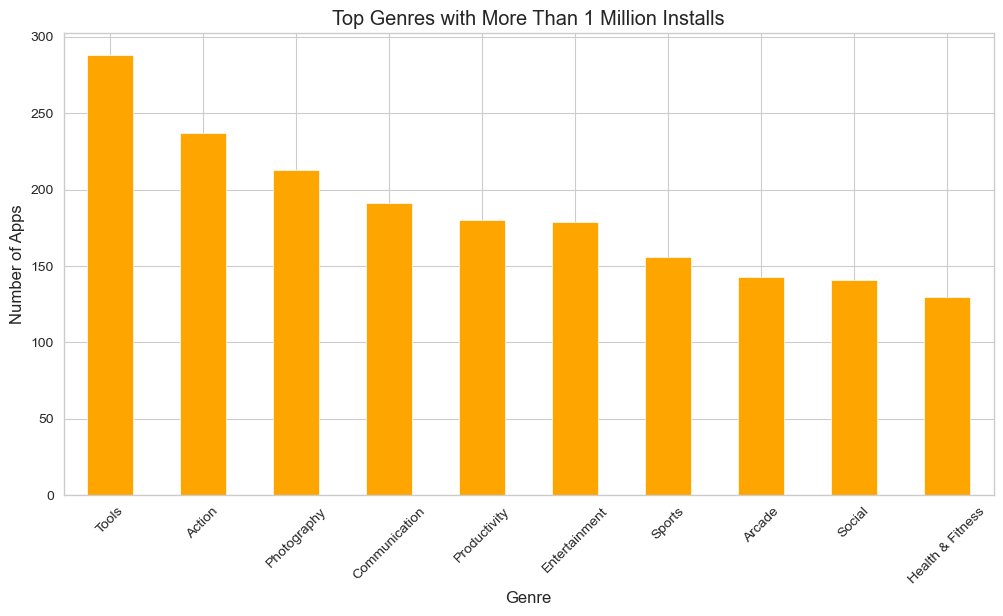

In [105]:
plt.figure(figsize=(12,6))

genre_installs.plot(kind='bar', color='orange')

plt.title("Top Genres with More Than 1 Million Installs")

plt.xlabel("Genre")

plt.ylabel("Number of Apps")

plt.xticks(rotation=45)
save_plot("Top Genres with More than 1 Million installs")
plt.show()

In [74]:
# Question 16: App Update Trend

df['Update Year'] = df['Last Updated'].dt.year

update_trend = df['Update Year'].value_counts().sort_index()

update_trend

Update Year
2010       1
2011      15
2012      26
2013     107
2014     204
2015     454
2016     787
2017    1823
2018    6929
Name: count, dtype: int64

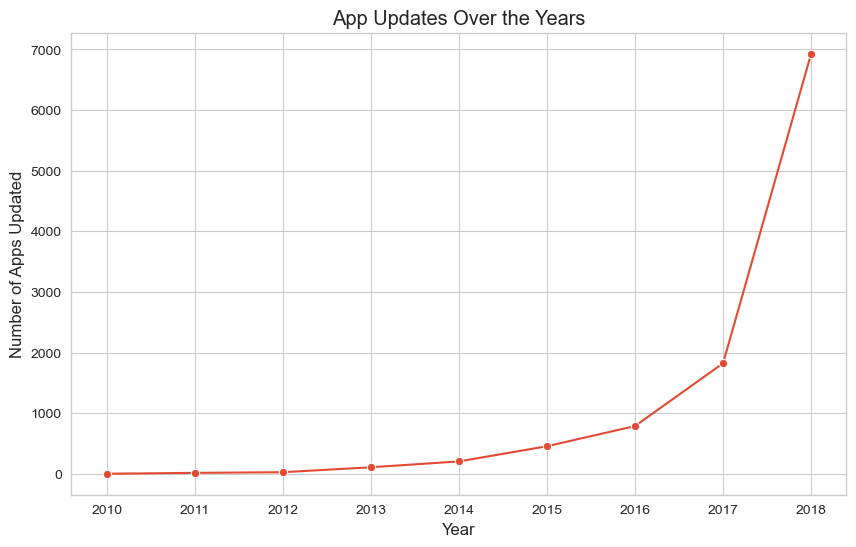

In [106]:
plt.figure(figsize=(10,6))

sns.lineplot(x=update_trend.index, y=update_trend.values, marker='o')

plt.title("App Updates Over the Years")

plt.xlabel("Year")

plt.ylabel("Number of Apps Updated")
save_plot("App Updates over the Years")
plt.show()

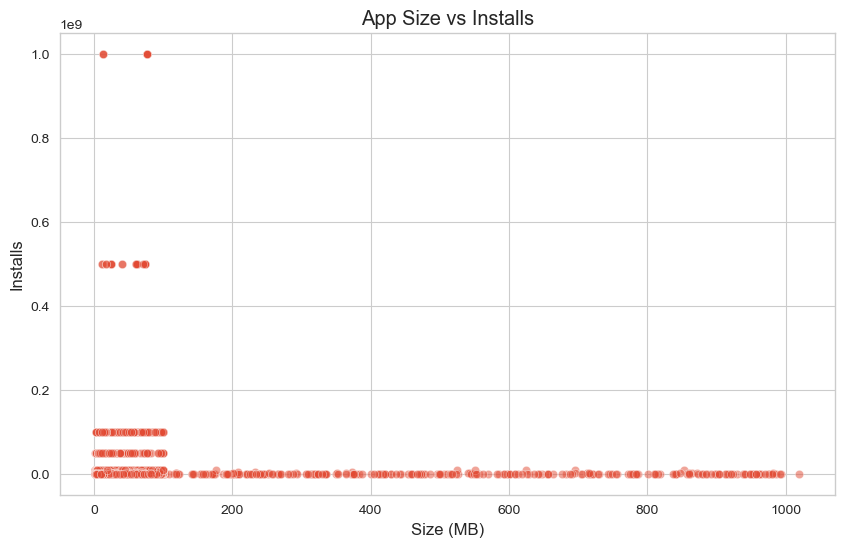

In [107]:
# Question 17: App Size vs Installs

plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='Size', y='Installs', alpha=0.5)

plt.title("App Size vs Installs")

plt.xlabel("Size (MB)")

plt.ylabel("Installs")
save_plot("App Size vs Installs")
plt.show()

In [77]:
# Question 18: Top Apps by Reviews

top_reviews = df[['App','Reviews','Rating']].sort_values(
    by='Reviews',
    ascending=False
).head(10)

top_reviews

,App,Reviews,Rating
2544,Facebook,78158306,4.1
3943,Facebook,78128208,4.1
336,WhatsApp Messenger,69119316,4.4
3904,WhatsApp Messenger,69109672,4.4
2604,Instagram,66577446,4.5
2545,Instagram,66577313,4.5
3909,Instagram,66509917,4.5
382,Messenger – Text and Video Chat for Free,56646578,4.0
335,Messenger – Text and Video Chat for Free,56642847,4.0
1879,Clash of Clans,44893888,4.6


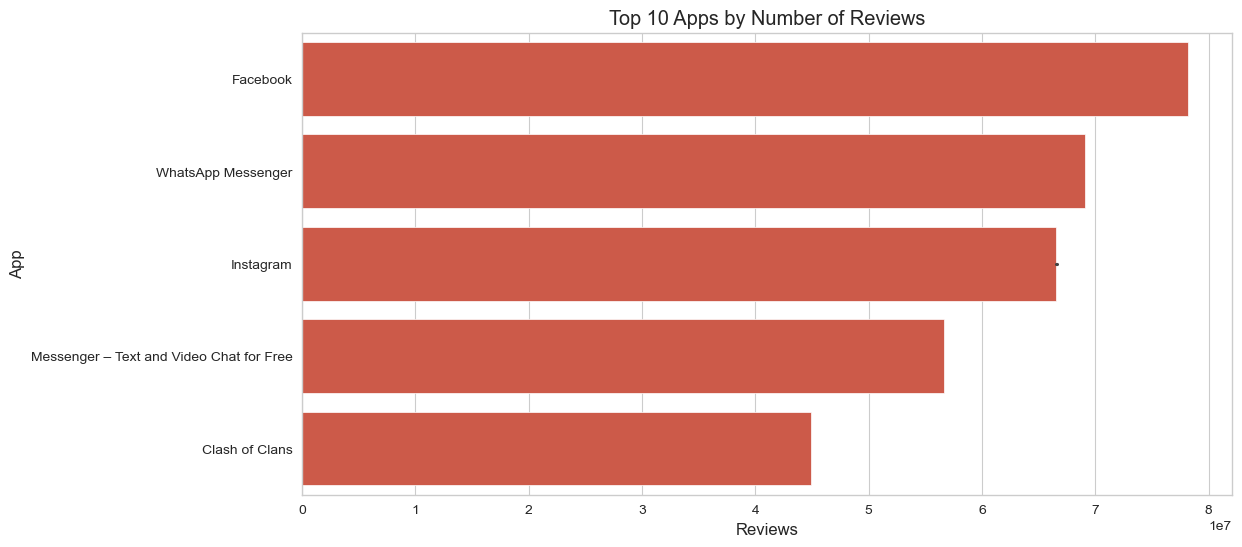

In [108]:
plt.figure(figsize=(12,6))

sns.barplot(data=top_reviews, x='Reviews', y='App')

plt.title("Top 10 Apps by Number of Reviews")
save_plot("Top 10 apps by Number of reviews")
plt.show()

In [79]:
# Question 19: Content Rating Distribution by App Type

content_type = pd.crosstab(df['Content Rating'], df['Type'])

content_type

Type,Free,Paid
Content Rating,,
Adults only 18+,3,0
Everyone,7713,659
Everyone 10+,344,32
Mature 17+,428,19
Teen,1094,52
Unrated,2,0


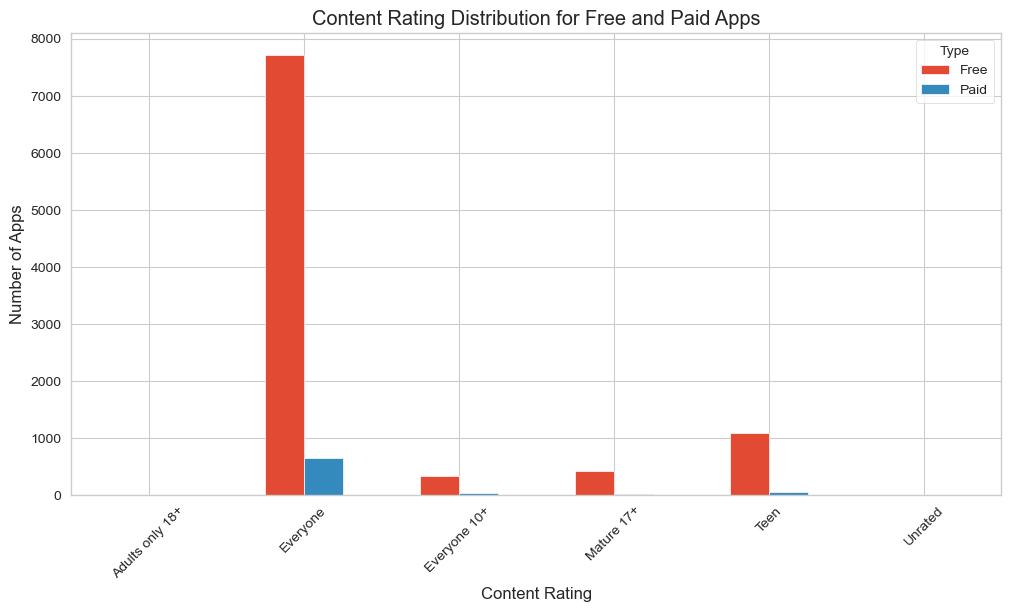

In [109]:
content_type.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Content Rating Distribution for Free and Paid Apps")

plt.xlabel("Content Rating")

plt.ylabel("Number of Apps")

plt.xticks(rotation=45)
save_plot("Content Rating Distribution for free and paid apps")
plt.show()

In [81]:
# Question 20: Top 5 Categories by Total Installs

top_categories = df.groupby('Category')['Installs'].sum().sort_values(
    ascending=False
).head(5)

top_categories

Category
GAME             31544024415
COMMUNICATION    24152276251
SOCIAL           12513867902
PRODUCTIVITY     12463091369
TOOLS            11452271905
Name: Installs, dtype: int64

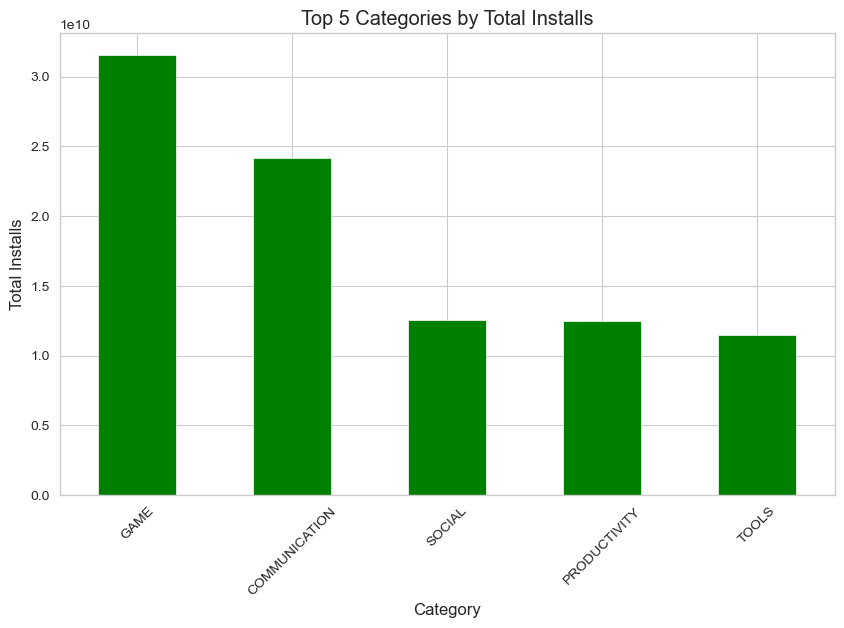

In [110]:
plt.figure(figsize=(10,6))

top_categories.plot(kind='bar', color='green')

plt.title("Top 5 Categories by Total Installs")

plt.xlabel("Category")

plt.ylabel("Total Installs")

plt.xticks(rotation=45)
save_plot("Top 5 Categories by Total Installs")
plt.show()

In [84]:
# Question 21: Top 10 Highest Rated Apps

top_rated_apps = df[['App', 'Category', 'Rating', 'Reviews', 'Installs']].sort_values(
    by='Rating',
    ascending=False
).head(10)

top_rated_apps

,App,Category,Rating,Reviews,Installs
6727,BS-Mobile,COMMUNICATION,5.0,1,50
6396,Bk Usha behn,LIFESTYLE,5.0,10,1000
5685,Jobs in Canada - Emplois au Canada,BUSINESS,5.0,2,1000
7506,CL REPL,TOOLS,5.0,47,1000
9498,EK Bailey Preaching Conference,EVENTS,5.0,3,500
8018,30WPM Amateur ham radio Koch CW Morse code tra...,FAMILY,5.0,1,10
7514,CL Keyboard - Myanmar Keyboard (No Ads),TOOLS,5.0,24,5000
7517,CL Notifier,TOOLS,5.0,36,100
8014,Morse Player,FAMILY,5.0,12,100
9496,Master E.K,FAMILY,5.0,90,1000


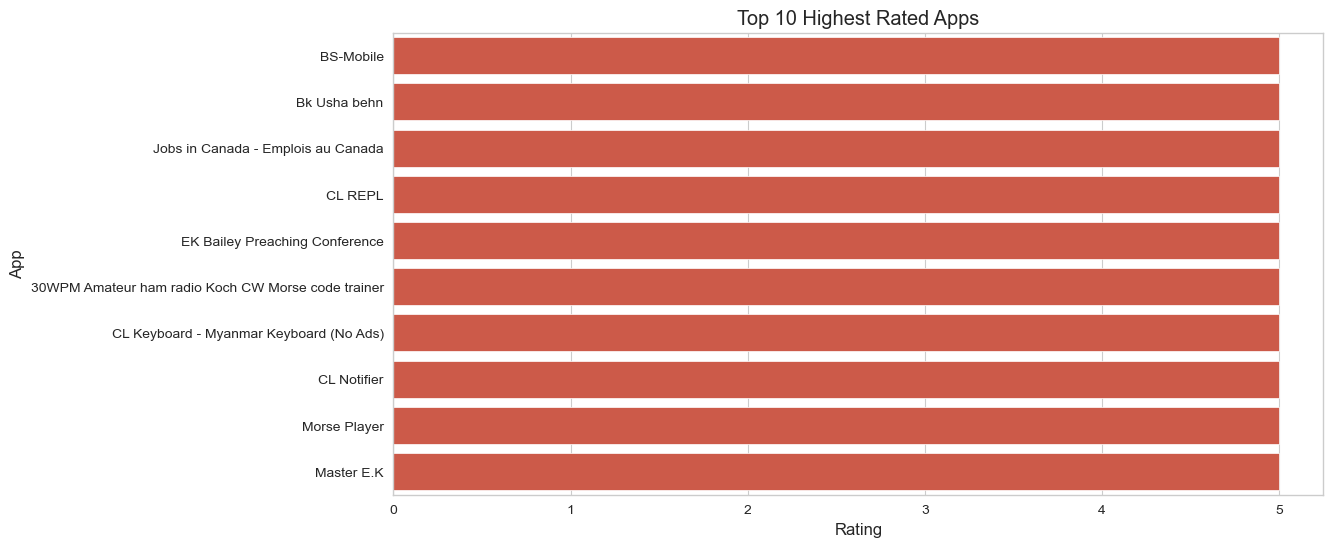

In [111]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rated_apps,
    x='Rating',
    y='App'
)

plt.title("Top 10 Highest Rated Apps")

plt.xlabel("Rating")

plt.ylabel("App")
save_plot("Top 10 Highest Rated apps")
plt.show()

In [86]:
# Question 22: Trend of App Updates Over Time

update_trend = df['Last Updated'].dt.year.value_counts().sort_index()

update_trend

Last Updated
2010       1
2011      15
2012      26
2013     107
2014     204
2015     454
2016     787
2017    1823
2018    6929
Name: count, dtype: int64

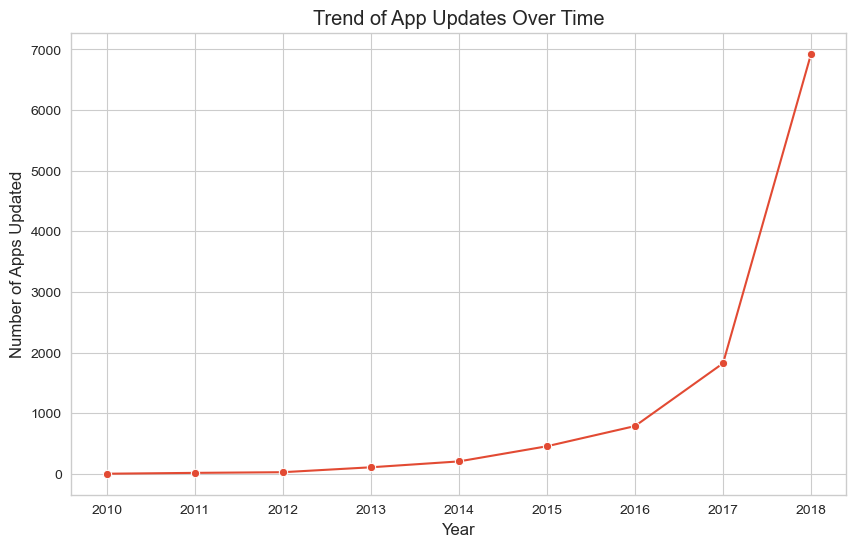

In [112]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=update_trend.index,
    y=update_trend.values,
    marker='o'
)

plt.title("Trend of App Updates Over Time")

plt.xlabel("Year")

plt.ylabel("Number of Apps Updated")
save_plot("Trend Of App Updated over time")
plt.show()

In [88]:
# Question 23: Average Rating by Install Groups

bins = [0,1000,10000,100000,1000000,10000000,100000000,1000000000]

labels = [
    '0-1K',
    '1K-10K',
    '10K-100K',
    '100K-1M',
    '1M-10M',
    '10M-100M',
    '100M+'
]

df['Install Group'] = pd.cut(
    df['Installs'],
    bins=bins,
    labels=labels
)

rating_by_install = df.groupby('Install Group')['Rating'].mean()

rating_by_install

Install Group
0-1K        4.248986
1K-10K      4.046765
10K-100K    4.098627
100K-1M     4.207239
1M-10M      4.285675
10M-100M    4.382995
100M+       4.309091
Name: Rating, dtype: float64

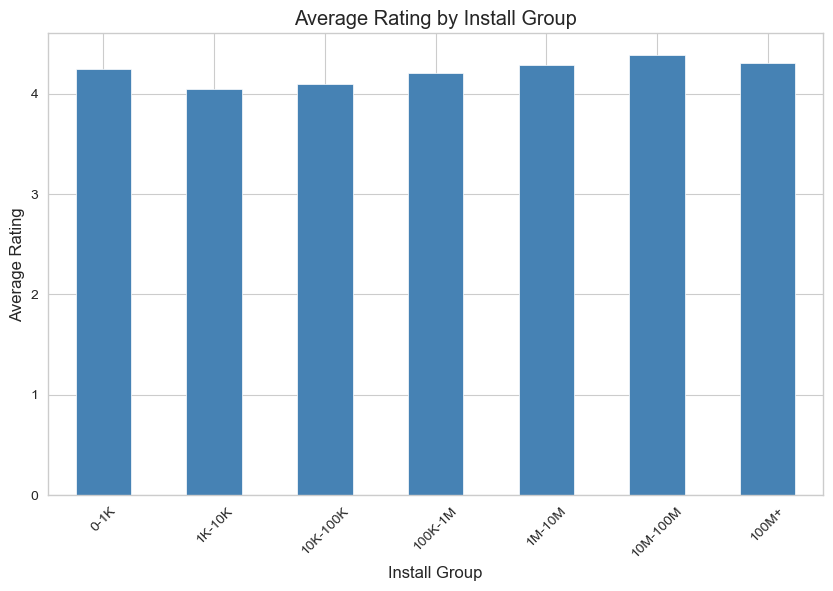

In [113]:
plt.figure(figsize=(10,6))

rating_by_install.plot(
    kind='bar',
    color='steelblue'
)

plt.title("Average Rating by Install Group")

plt.xlabel("Install Group")

plt.ylabel("Average Rating")

plt.xticks(rotation=45)
save_plot("Average Rating by Install Group")
plt.show()

In [91]:
# Question 25: Genre vs Average Rating

genre_rating = df.groupby('Genres')['Rating'].mean().sort_values(
    ascending=False
).head(10)

genre_rating

Genres
Board;Pretend Play             4.800000
Comics;Creativity              4.800000
Health & Fitness;Education     4.700000
Adventure;Brain Games          4.600000
Puzzle;Education               4.600000
Strategy;Action & Adventure    4.600000
Entertainment;Creativity       4.533333
Music;Music & Video            4.533333
Racing;Pretend Play            4.500000
Arcade;Pretend Play            4.500000
Name: Rating, dtype: float64

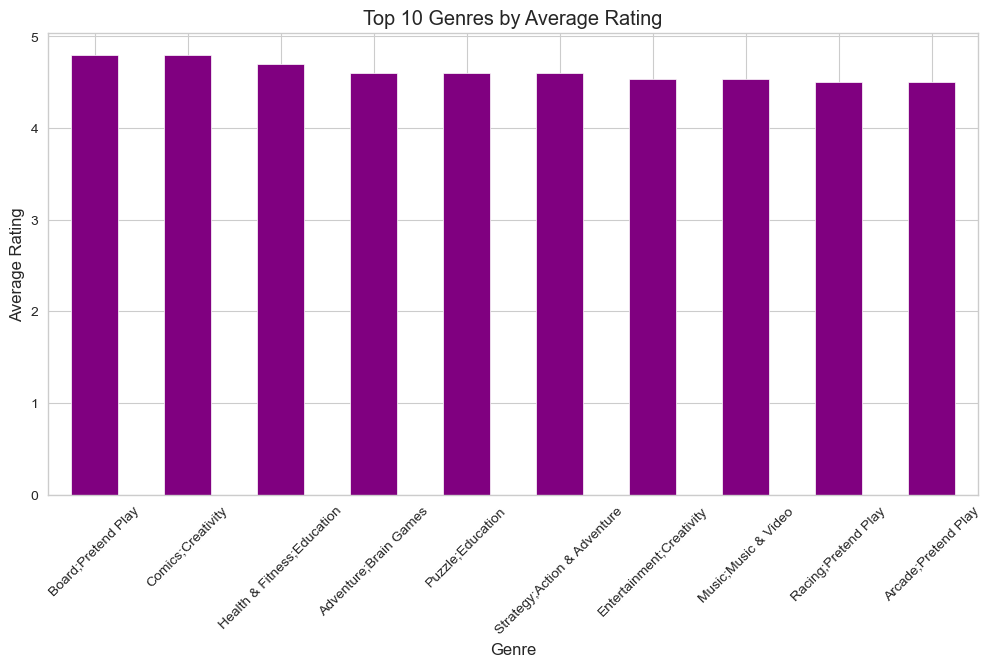

In [114]:
plt.figure(figsize=(12,6))

genre_rating.plot(
    kind='bar',
    color='purple'
)

plt.title("Top 10 Genres by Average Rating")

plt.xlabel("Genre")

plt.ylabel("Average Rating")

plt.xticks(rotation=45)
save_plot("Top 10 Genres by Average Rating")
plt.show()